# OSEL - Optimized Stacking Ensemble Learning

Notebook nay cai dat truc tiep OSEL cho bai toan time series. OSEL ket hop nhieu base learners bang stacking va toi uu hyperparameter bang `TimeSeriesSplit`, khong shuffle du lieu.

In [1]:
from pathlib import Path
import json
import math
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import ParameterSampler, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.aq_course_ml.config import (
    CATEGORICAL_COLUMNS,
    FEATURE_COLUMNS,
    METRICS_PATH,
    MODEL_DIR,
    PREDICTION_PLOT_PATH,
    PROCESSED_DATA_PATH,
    RANDOM_STATE,
    RAIN_ALERT_THRESHOLD_MM,
    REGRESSION_MODEL_PATH,
    REGRESSION_TARGET,
    REPORT_DIR,
)
from src.aq_course_ml.train_model import build_preprocessor

TRAIN_START = '2020-01-01'
TRAIN_END = '2025-12-31 23:59:59'
TEST_START = '2026-01-01'
MODEL_FILE = MODEL_DIR / 'osel_regressor.joblib'
METRICS_FILE = REPORT_DIR / 'osel_metrics.json'
PLOT_FILE = REPORT_DIR / 'osel_predictions.png'

## Time-Series Stacking

Meta learner chi duoc hoc tu out-of-fold predictions duoc tao theo thu tu thoi gian: train tren qua khu, predict tren validation o tuong lai.

In [2]:
class TimeSeriesStackingRegressor(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        cv_splits=3,
        random_state=None,
        n_jobs=-1,
        passthrough=False,
        rf_n_estimators=180,
        rf_max_depth=10,
        rf_min_samples_leaf=4,
        extra_n_estimators=180,
        extra_max_depth=14,
        extra_min_samples_leaf=4,
        lgbm_n_estimators=200,
        lgbm_learning_rate=0.03,
        lgbm_num_leaves=31,
        lgbm_subsample=0.8,
        lgbm_colsample_bytree=0.8,
        xgb_n_estimators=200,
        xgb_learning_rate=0.03,
        xgb_max_depth=5,
        xgb_subsample=0.8,
        xgb_colsample_bytree=0.8,
        ridge_alpha=50.0,
        final_alpha=1.0,
    ):
        self.cv_splits = cv_splits
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.passthrough = passthrough
        self.rf_n_estimators = rf_n_estimators
        self.rf_max_depth = rf_max_depth
        self.rf_min_samples_leaf = rf_min_samples_leaf
        self.extra_n_estimators = extra_n_estimators
        self.extra_max_depth = extra_max_depth
        self.extra_min_samples_leaf = extra_min_samples_leaf
        self.lgbm_n_estimators = lgbm_n_estimators
        self.lgbm_learning_rate = lgbm_learning_rate
        self.lgbm_num_leaves = lgbm_num_leaves
        self.lgbm_subsample = lgbm_subsample
        self.lgbm_colsample_bytree = lgbm_colsample_bytree
        self.xgb_n_estimators = xgb_n_estimators
        self.xgb_learning_rate = xgb_learning_rate
        self.xgb_max_depth = xgb_max_depth
        self.xgb_subsample = xgb_subsample
        self.xgb_colsample_bytree = xgb_colsample_bytree
        self.ridge_alpha = ridge_alpha
        self.final_alpha = final_alpha

    def fit(self, X, y):
        y = np.asarray(y, dtype=float)
        base_models = self._build_base_models()
        oof_predictions = np.full((len(X), len(base_models)), np.nan)
        splitter = TimeSeriesSplit(n_splits=self.cv_splits)

        for train_index, valid_index in splitter.split(X):
            X_train_fold = self._take_rows(X, train_index)
            X_valid_fold = self._take_rows(X, valid_index)
            y_train_fold = y[train_index]

            for model_index, (_, estimator) in enumerate(base_models):
                fold_model = clone(estimator)
                fold_model.fit(X_train_fold, y_train_fold)
                oof_predictions[valid_index, model_index] = fold_model.predict(X_valid_fold)

        meta_rows = ~np.isnan(oof_predictions).any(axis=1)
        if not np.any(meta_rows):
            raise ValueError('Not enough rows to build time-series stacking meta-features.')

        if self.passthrough:
            self.passthrough_preprocessor_ = build_preprocessor()
            self.passthrough_preprocessor_.fit(self._take_rows(X, np.flatnonzero(meta_rows)))

        meta_X = self._combine_features(oof_predictions[meta_rows], self._take_rows(X, np.flatnonzero(meta_rows)))
        self.final_estimator_ = Ridge(alpha=self.final_alpha)
        self.final_estimator_.fit(meta_X, y[meta_rows])

        self.base_models_ = []
        for name, estimator in base_models:
            fitted = clone(estimator)
            fitted.fit(X, y)
            self.base_models_.append((name, fitted))
        return self

    def predict(self, X):
        base_predictions = np.column_stack([model.predict(X) for _, model in self.base_models_])
        return self.final_estimator_.predict(self._combine_features(base_predictions, X))

    def _build_base_models(self):
        return [
            ('ada', self._pipeline(AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=8, min_samples_leaf=2), learning_rate=0.03, n_estimators=80))),
            ('rf', self._pipeline(RandomForestRegressor(
                n_estimators=self.rf_n_estimators,
                max_depth=self.rf_max_depth,
                min_samples_leaf=self.rf_min_samples_leaf,
                random_state=self.random_state,
                n_jobs=self.n_jobs,
            ))),
            ('extra', self._pipeline(ExtraTreesRegressor(
                n_estimators=self.extra_n_estimators,
                max_depth=self.extra_max_depth,
                min_samples_leaf=self.extra_min_samples_leaf,
                random_state=self.random_state,
                n_jobs=self.n_jobs,
            ))),
            ('lgbm', self._pipeline(LGBMRegressor(
                n_estimators=self.lgbm_n_estimators,
                learning_rate=self.lgbm_learning_rate,
                num_leaves=self.lgbm_num_leaves,
                subsample=self.lgbm_subsample,
                colsample_bytree=self.lgbm_colsample_bytree,
                random_state=self.random_state,
                n_jobs=self.n_jobs,
                verbosity=-1,
            ))),
            ('xgb', self._pipeline(XGBRegressor(
                n_estimators=self.xgb_n_estimators,
                learning_rate=self.xgb_learning_rate,
                max_depth=self.xgb_max_depth,
                subsample=self.xgb_subsample,
                colsample_bytree=self.xgb_colsample_bytree,
                random_state=self.random_state,
                n_jobs=self.n_jobs,
                objective='reg:squarederror',
            ))),
        ]

    @staticmethod
    def _pipeline(estimator):
        return Pipeline([
            ('preprocess', build_preprocessor()),
            ('model', estimator),
        ])

    def _combine_features(self, base_predictions, X):
        if self.passthrough:
            passthrough_features = self.passthrough_preprocessor_.transform(X)
            if hasattr(passthrough_features, 'toarray'):
                passthrough_features = passthrough_features.toarray()
            return np.hstack([base_predictions, passthrough_features])
        return base_predictions

    @staticmethod
    def _take_rows(X, row_index):
        if hasattr(X, 'iloc'):
            return X.iloc[row_index]
        return X[row_index]


## Train And Evaluate

In [3]:
df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['timestamp'])
train_df = df[(df['timestamp'] >= TRAIN_START) & (df['timestamp'] <= TRAIN_END)].copy()
test_df = df[df['timestamp'] >= TEST_START].copy()

print('Rows:', {'total': len(df), 'train': len(train_df), 'test': len(test_df)})
print('Train:', train_df['timestamp'].min(), '->', train_df['timestamp'].max())
print('Test:', test_df['timestamp'].min(), '->', test_df['timestamp'].max())

if train_df.empty or test_df.empty:
    raise ValueError('Train/test split is empty. Crawl data from 2020-01-01 through the current date first.')

x_train = train_df[FEATURE_COLUMNS + CATEGORICAL_COLUMNS]
y_train = train_df[REGRESSION_TARGET]
x_test = test_df[FEATURE_COLUMNS + CATEGORICAL_COLUMNS]
y_test = test_df[REGRESSION_TARGET]

model = TimeSeriesStackingRegressor()
model.fit(x_train, y_train)



Rows: {'total': 56094, 'train': 52596, 'test': 3498}
Train: 2020-01-01 12:00:00 -> 2025-12-31 23:00:00
Test: 2026-01-01 00:00:00 -> 2026-05-26 17:00:00


TimeSeriesStackingRegressor()

In [4]:
predictions = model.predict(x_test)

regression_metrics = {
    'mae': float(mean_absolute_error(y_test, predictions)),
    'rmse': float(math.sqrt(mean_squared_error(y_test, predictions))),
    'r2': float(r2_score(y_test, predictions)),
}
regression_metrics

{'mae': 0.8342392062031687,
 'rmse': 2.519528633141719,
 'r2': 0.3335708653573183}

In [5]:
alert_predictions = (predictions >= RAIN_ALERT_THRESHOLD_MM).astype(int)
alert_metrics = {
    'accuracy': float(accuracy_score(test_df['target_rain_alert_6h'], alert_predictions)),
    'f1': float(f1_score(test_df['target_rain_alert_6h'], alert_predictions, zero_division=0)),
    'confusion_matrix': confusion_matrix(test_df['target_rain_alert_6h'], alert_predictions, labels=[0, 1]).tolist(),
    'classification_report': classification_report(
        test_df['target_rain_alert_6h'],
        alert_predictions,
        labels=[0, 1],
        zero_division=0,
        output_dict=True,
    ),
}
alert_metrics

{'accuracy': 0.8862206975414523,
 'f1': 0.6294227188081937,
 'confusion_matrix': [[2762, 277], [121, 338]],
 'classification_report': {'0': {'precision': 0.9580298300381547,
   'recall': 0.9088515959197104,
   'f1-score': 0.9327929753461668,
   'support': 3039.0},
  '1': {'precision': 0.5495934959349593,
   'recall': 0.7363834422657952,
   'f1-score': 0.6294227188081937,
   'support': 459.0},
  'accuracy': 0.8862206975414523,
  'macro avg': {'precision': 0.753811662986557,
   'recall': 0.8226175190927528,
   'f1-score': 0.7811078470771802,
   'support': 3498.0},
  'weighted avg': {'precision': 0.9044356970040305,
   'recall': 0.8862206975414523,
   'f1-score': 0.8929853859376676,
   'support': 3498.0}}}

## Save Artifacts

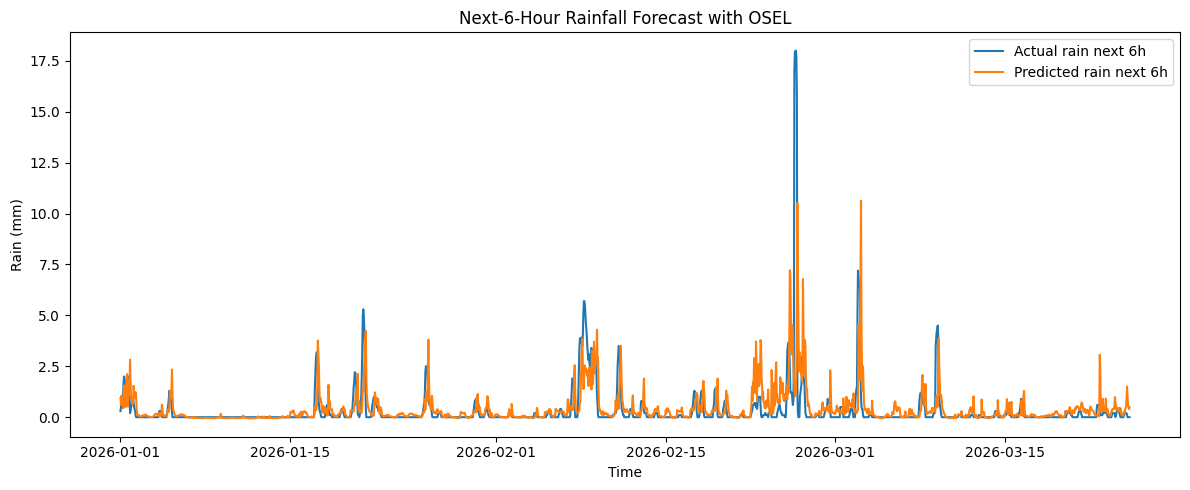

Model: D:\air-quality-course-ml\Notebooks\models\osel_regressor.joblib
Metrics: D:\air-quality-course-ml\Results\osel_metrics.json
Plot: D:\air-quality-course-ml\Results\osel_predictions.png


In [6]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODEL_FILE)

preview = test_df[['timestamp', REGRESSION_TARGET]].copy()
preview['predicted_rain_next_6h'] = predictions
preview = preview.sort_values('timestamp').head(2000)

plt.figure(figsize=(12, 5))
plt.plot(preview['timestamp'], preview[REGRESSION_TARGET], label='Actual rain next 6h')
plt.plot(preview['timestamp'], preview['predicted_rain_next_6h'], label='Predicted rain next 6h')
plt.xlabel('Time')
plt.ylabel('Rain (mm)')
plt.title('Next-6-Hour Rainfall Forecast with OSEL')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=150)
plt.show()

metrics = {
    'model': 'OSEL - Optimized Stacking Ensemble Learning',
    'train_period': ['2020-01-01', '2025-12-31'],
    'test_period': ['2026-01-01', str(test_df['timestamp'].max())],
    'rows': {'total': int(len(df)), 'train': int(len(train_df)), 'test': int(len(test_df))},
    'regression_rain_next_6h_osel': regression_metrics,
    'rain_alert_from_regression_6h': alert_metrics,
    'osel_base_models': [name for name, _ in model.base_models_],
    'osel_final_alpha': model.final_alpha,
    'osel_cv_splits': model.cv_splits,
}
METRICS_FILE.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding='utf-8')

print('Model:', MODEL_FILE)
print('Metrics:', METRICS_FILE)
print('Plot:', PLOT_FILE)